# Przykłady: złożoność

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from timeit import timeit

In [1]:
def silnia_iter(n):
    silnia = 1;
    for i in range(2, n+1):
        silnia *= i; # op. dom.
    return silnia;

In [ ]:
def suma(tab):
    suma=0;
    for x in tab:
        suma += x # op. dom. 

    return suma;

In [2]:
def szukaj2(x, lista):
    """
        Szukamy *x* na liście. Jeśli jest, zwracamy jego indeks, jeśli nie ma zwracamy *None*.
    """
    for i, el in enumerate(lista):
        if(el == x): # op. dom.
            return i;

    return None;

In [4]:
list(range(7))

[0, 1, 2, 3, 4, 5, 6]

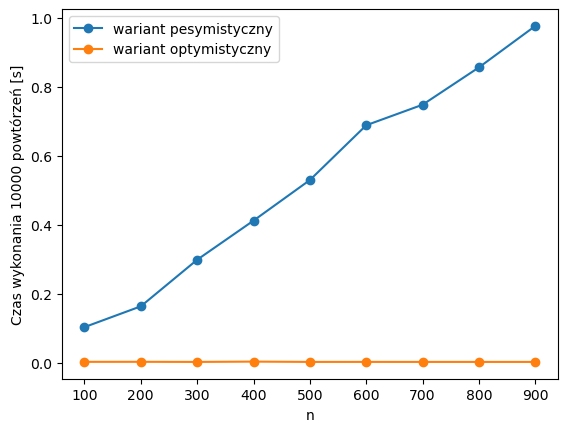

In [7]:
ns = np.arange(100, 1000, 100)
timesp = [];
timeso = [];
reps = 10000;

for n in ns:
    lista = list(range(n));
    x = n+1;    
    timesp.append(timeit("szukaj2(x, lista)", globals=globals(), number=reps))
    x = 0;    
    timeso.append(timeit("szukaj2(x, lista)", globals=globals(), number=reps))

plt.plot(ns, timesp, marker="o", label="wariant pesymistyczny")
plt.plot(ns, timeso, marker="o", label="wariant optymistyczny")
plt.xlabel("n");
plt.ylabel(f"Czas wykonania {reps} powtórzeń [s]");
plt.legend()

In [9]:
def bisekcja1(x, lista):
    """
        Szukamy *x* na posortowanej liście. Jeśli jest, zwracamy jego indeks, jeśli nie ma zwracamy *None*.
    """
    a = 0;
    b = len(lista);

    while(a<b):
        c = (a+b)//2; # op. dom.
        #print(lista[c], lista[a:b])
        if(lista[c] == x):
            return c;
        elif(lista[c] > x):
            b = c;
        else:
            a = c+1;

    return None;
    

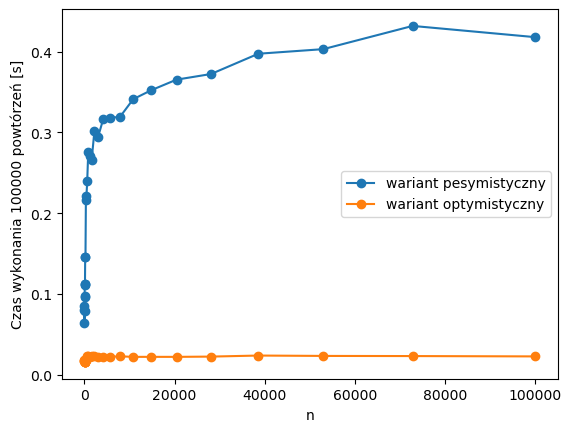

In [10]:
ns = np.geomspace(10, 100000, 30, dtype=int)
timesp = [];
timeso = [];
reps = 100000;

for n in ns:
    lista = list(range(n));
    x = n+1;    
    timesp.append(timeit("bisekcja1(x, lista)", globals=globals(), number=reps))
    x = n//2;    
    timeso.append(timeit("bisekcja1(x, lista)", globals=globals(), number=reps))

plt.plot(ns, timesp, marker="o", label="wariant pesymistyczny")
plt.plot(ns, timeso, marker="o", label="wariant optymistyczny")
plt.xlabel("n");
plt.ylabel(f"Czas wykonania {reps} powtórzeń [s]");
plt.legend()

In [11]:
np.geomspace(10, 100000, 30, dtype=int)

array([    10,     13,     18,     25,     35,     48,     67,     92,
          126,    174,    239,    329,    452,    621,    853,   1172,
         1610,   2212,   3039,   4175,   5736,   7880,  10826,  14873,
        20433,  28072,  38566,  52983,  72789, 100000])

In [13]:
def czy_pierwsza(n):
    if(n<=1):
        return False;
    for i in range(2, int(n**0.5)+1):
        if(n%i == 0): # op. dom. 
            return False;
    return True;

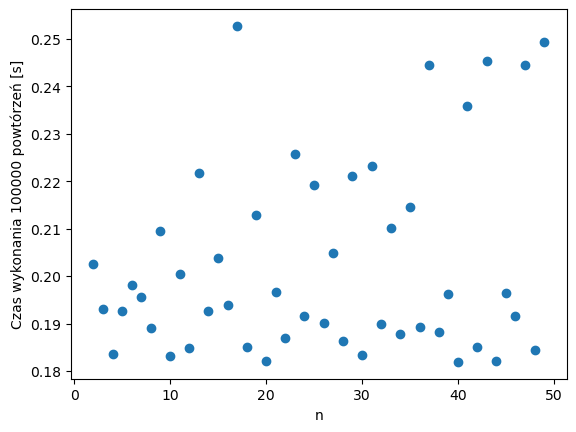

In [16]:
ns = np.arange(2, 50, 1)
times = [];
reps = 100000;

for n in ns: 
    times.append(timeit("czy_pierwsza(n)", globals=globals(), number=reps))

plt.plot(ns, times, marker="o", ls="none")
plt.xlabel("n");
plt.ylabel(f"Czas wykonania {reps} powtórzeń [s]");

In [18]:
def scal_posortowane(tab1, tab2):
    polaczona = [];

    i1=0
    i2=0

    while True:
        if(i1 >= len(tab1)):
            polaczona += tab2[i2:]; # to też trzeba uwzględnić, raczej nie O(1)
            break;
        if(i2 >= len(tab2)):
            polaczona += tab1[i1:]; # to też trzeba uwzględnić, raczej nie O(1)
            break;
            
        if(tab1[i1] <= tab2[i2]): # op. dom. 
            polaczona.append(tab1[i1]);
            i1 += 1
        else:
            polaczona.append(tab2[i2]);
            i2 += 1

    return polaczona;

In [21]:
import random

In [25]:
lista = list(range(20))
print(lista)
random.shuffle(lista)
print(lista)
p = len(lista)//2
l1 = lista[:p]
l2 = lista[p:]
print(l1)
print(l2)
l1.sort()
l2.sort()
print(l1)
print(l2)


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
[17, 16, 12, 18, 5, 13, 15, 4, 0, 3, 2, 8, 7, 9, 14, 19, 11, 1, 10, 6]
[17, 16, 12, 18, 5, 13, 15, 4, 0, 3]
[2, 8, 7, 9, 14, 19, 11, 1, 10, 6]
[0, 3, 4, 5, 12, 13, 15, 16, 17, 18]
[1, 2, 6, 7, 8, 9, 10, 11, 14, 19]


C:\Users\Konrad\AppData\Local\Temp\ipykernel_18980\2519474993.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


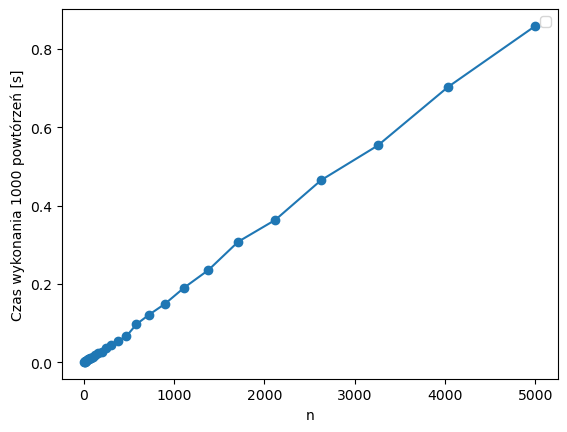

In [27]:
ns = np.geomspace(10, 5000, 30, dtype=int)
timesp = [];
reps = 1000;

for n in ns:
    lista = list(range(n))
    random.shuffle(lista)
    p = len(lista)//2
    l1 = lista[:p]
    l2 = lista[p:]
    l1.sort()
    l2.sort()
    timesp.append(timeit("scal_posortowane(l1, l2)", globals=globals(), number=reps))

plt.plot(ns, timesp, marker="o")
plt.xlabel("n");
plt.ylabel(f"Czas wykonania {reps} powtórzeń [s]");
plt.legend()